In [1]:
import numpy as np 
from astropy.table import Table

In [2]:
# --- plotting ---
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rcParams['text.usetex'] = True
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['axes.linewidth'] = 1.5
mpl.rcParams['axes.xmargin'] = 1
mpl.rcParams['xtick.labelsize'] = 'x-large'
mpl.rcParams['xtick.major.size'] = 5
mpl.rcParams['xtick.major.width'] = 1.5
mpl.rcParams['ytick.labelsize'] = 'x-large'
mpl.rcParams['ytick.major.size'] = 5
mpl.rcParams['ytick.major.width'] = 1.5
mpl.rcParams['legend.frameon'] = False

In [3]:
kota = Table.read('/Users/hahnchanghoon/data/pfs/kota_vi_run21_extra.fits')

In [4]:
# LAM 1D reduction for S25a sent by Jingjing
lam1d_s25a = Table.read('/Users/hahnchanghoon/data/pfs/lam1d_s25a_matched.fits')

In [9]:
for subclass in np.unique(lam1d_s25a['subClass']): 
    print('%s %.3f' % (subclass, np.mean(lam1d_s25a['subClass'] == subclass)))

BX_SB1 0.039
BX_SB3 0.047
BX_Scd 0.057
Irr 0.029
Irr_Blue 0.077
Irr_highOII 0.018
Lya_abs_SB1 0.062
Lya_abs_SB3 0.067
Lya_abs_Scd 0.051
Lya_em_SB1 0.310
Lya_em_SB3 0.070
Lya_em_Scd 0.035
SB2 0.074
Sbc 0.065


# quick look through LAM 1D

In [10]:
# only with good LAM 1D redshifts
good_lam = ((lam1d_s25a['probaGalaxy'] > 0.95) & 
           (lam1d_s25a['redshiftProba'] > 0.95) & 
           (lam1d_s25a['redshiftError'] < 0.01))
best_lam = ((lam1d_s25a['probaGalaxy'] > 0.99) & 
           (lam1d_s25a['redshiftProba'] > 0.99) & 
           (lam1d_s25a['redshiftError'] < 0.01))
print('LAM-GOOD %.3f' % np.mean(good_lam))
print('LAM-BEST %.3f' % np.mean(best_lam))

lam_lowz = ((lam1d_s25a['redshift'] > 0.6) & (lam1d_s25a['redshift'] < 1.6))
lam_highz = ((lam1d_s25a['redshift'] > 1.6) & (lam1d_s25a['redshift'] < 2.4))

LAM-GOOD 0.708
LAM-BEST 0.637


lets check out the data

([], [])

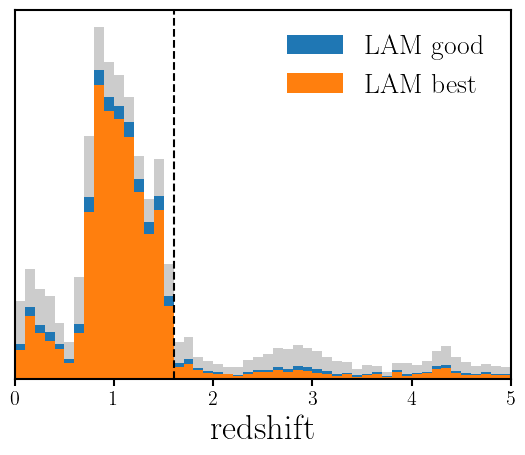

In [12]:
plt.hist(lam1d_s25a['redshift'], color='k', alpha=0.2, range=(0., 5.), bins=50)
plt.hist(lam1d_s25a['redshift'][good_lam], range=(0., 5.), bins=50, label='LAM good')
plt.hist(lam1d_s25a['redshift'][best_lam], range=(0., 5.), bins=50, label='LAM best')
plt.axvline(1.6, color='k', linestyle='--')
plt.legend(loc='upper right', fontsize=20)
plt.xlabel('redshift', fontsize=25)
plt.xlim(0., 5.)
plt.yticks([])

(0.0, 0.002)

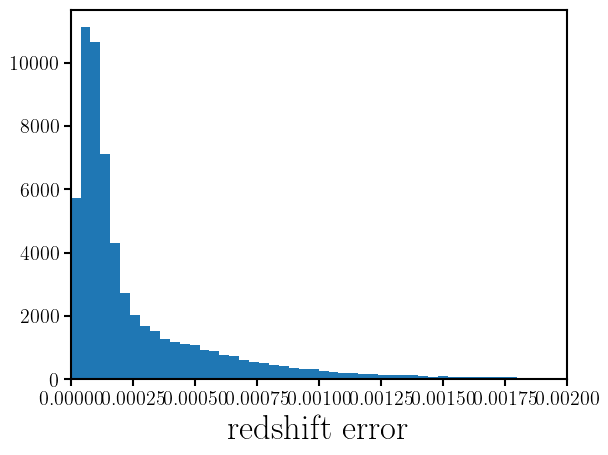

In [13]:
plt.hist(lam1d_s25a['redshiftError'], range=(0., 0.002), bins=50)
plt.xlabel('redshift error', fontsize=25)
plt.xlim(0., 0.002)

(0.0, 1.0)

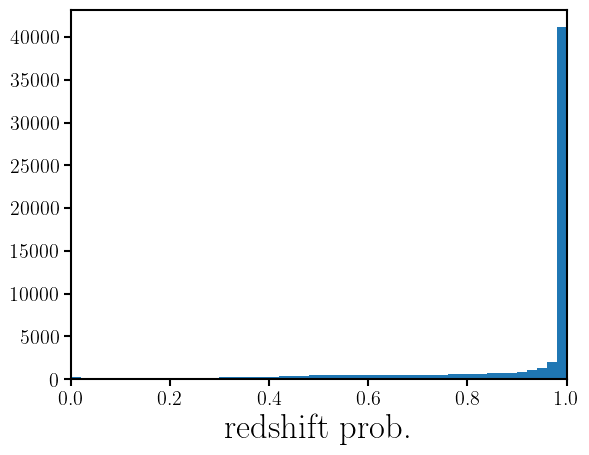

In [14]:
plt.hist(lam1d_s25a['redshiftProba'], range=(0., 1.), bins=50)
plt.xlabel('redshift prob.', fontsize=25)
plt.xlim(0., 1.)

(0.0, 1.0)

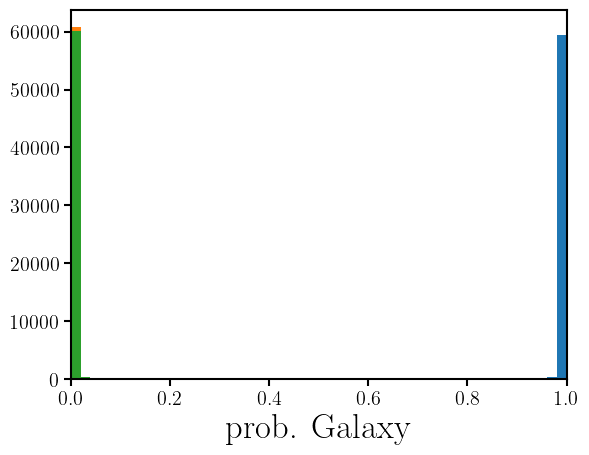

In [15]:
plt.hist(lam1d_s25a['probaGalaxy'], range=(0., 1.), bins=50)
plt.hist(lam1d_s25a['probaStar'], range=(0., 1.), bins=50)
plt.hist(lam1d_s25a['probaQSO'], range=(0., 1.), bins=50)
plt.xlabel('prob. Galaxy', fontsize=25)
plt.xlim(0., 1.)

0.1902762466766098


(0.0, 4.0)

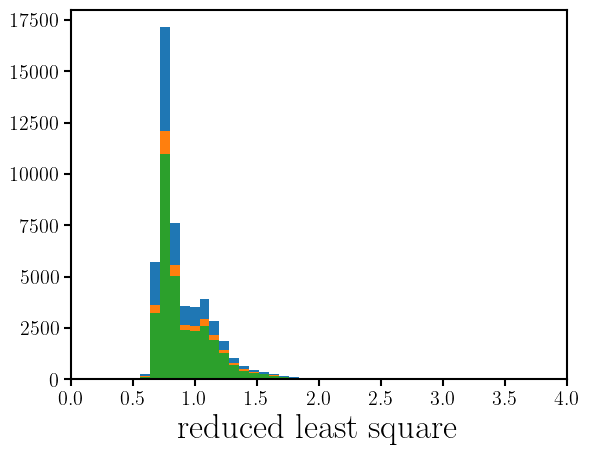

In [43]:
print(np.mean(lam1d_s25a['reducedLeastSquare'].mask))
plt.hist(lam1d_s25a['reducedLeastSquare'], range=(0., 4.), bins=50)
plt.hist(lam1d_s25a['reducedLeastSquare'][good_lam], range=(0., 4.), bins=50)
plt.hist(lam1d_s25a['reducedLeastSquare'][best_lam], range=(0., 4.), bins=50)
plt.xlabel('reduced least square', fontsize=25)
plt.xlim(0., 4)

# Compare Kota vs LAM1D

In [17]:
# match to Kota
i_match_kota = []
for objid in kota['objId']: 
    _match = (objid == lam1d_s25a['obj_id'])
    assert np.sum(_match) == 1

    i_match_kota.append(np.arange(len(lam1d_s25a))[_match])

i_match_kota = np.array(i_match_kota).flatten()

(Q_VI > 3) + (LAM good) 0.7954474586841285
(Q_VI > 3) + (LAM best) 0.8145695364238411
(Q_VI > 4) + (LAM good) 0.9146666666666666
(Q_VI > 4) + (LAM best) 0.9227567067530065


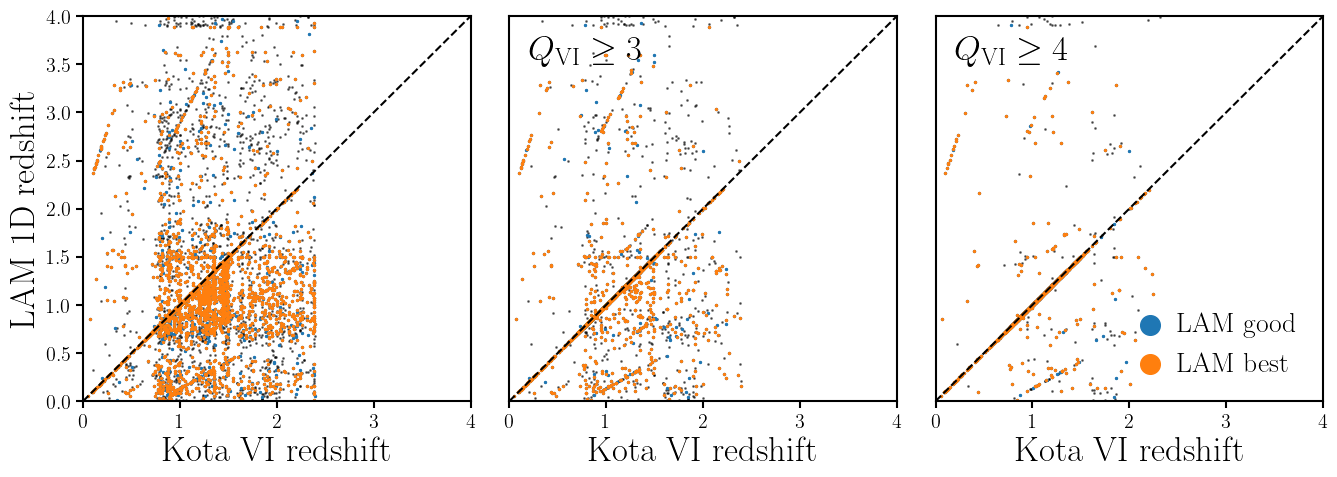

In [18]:
fig = plt.figure(figsize=(16,5))
sub = fig.add_subplot(131)
sub.plot([0., 4.], [0., 4.], c='k', ls='--')

# all matches
sub.scatter(kota['z_measured'], lam1d_s25a['redshift'][i_match_kota], c='k', alpha=0.5, s=1)

# only with good LAM 1D redshifts
_good_z = good_lam[i_match_kota]
sub.scatter(kota['z_measured'][_good_z], lam1d_s25a['redshift'][i_match_kota][_good_z], c='C0', s=2, label=r'${\rm LAM}$ good')

# only with good LAM 1D redshifts
_best_z = best_lam[i_match_kota]
sub.scatter(kota['z_measured'][_best_z], lam1d_s25a['redshift'][i_match_kota][_best_z], c='C1', s=2, label=r'${\rm LAM}$ best')

sub.set_xlabel(r'Kota VI redshift', fontsize=25)
sub.set_xlim(0., 4.)
sub.set_ylabel(r'LAM 1D redshift', fontsize=25)
sub.set_ylim(0., 4.)

# Q_VI > 3

sub = fig.add_subplot(132)
sub.plot([0., 4.], [0., 4.], c='k', ls='--')

q_thresh = 3.
pass_vi = 0.5*(kota['user1'] + kota['user2']) >= q_thresh

sub.text(0.05, 0.95, r'$Q_{\rm VI} \ge 3$', ha='left', va='top', transform=sub.transAxes, fontsize=25)

sub.scatter(kota['z_measured'][pass_vi], lam1d_s25a['redshift'][i_match_kota][pass_vi], c='k', alpha=0.5, s=1)
sub.scatter(kota['z_measured'][pass_vi & _good_z], lam1d_s25a['redshift'][i_match_kota][pass_vi & _good_z], c='C0', s=2, label=r'${\rm LAM}$ good')
sub.scatter(kota['z_measured'][pass_vi & _best_z], lam1d_s25a['redshift'][i_match_kota][pass_vi & _best_z], c='C1', s=2, label=r'${\rm LAM}$ best')

print('(Q_VI > 3) + (LAM good)', np.mean(np.abs(kota['z_measured'][pass_vi & _good_z] - lam1d_s25a['redshift'][i_match_kota][pass_vi & _good_z]) < 0.01))
print('(Q_VI > 3) + (LAM best)', np.mean(np.abs(kota['z_measured'][pass_vi & _best_z] - lam1d_s25a['redshift'][i_match_kota][pass_vi & _best_z]) < 0.01))

sub.set_xlabel(r'Kota VI redshift', fontsize=25)
sub.set_xlim(0., 4.)
sub.set_ylim(0., 4.)
sub.set_yticks([])


sub = fig.add_subplot(133)
sub.plot([0., 4.], [0., 4.], c='k', ls='--')

q_thresh = 4.
pass_vi = 0.5*(kota['user1'] + kota['user2']) >= q_thresh

sub.text(0.05, 0.95, r'$Q_{\rm VI} \ge 4$', ha='left', va='top', transform=sub.transAxes, fontsize=25)

sub.scatter(kota['z_measured'][pass_vi], lam1d_s25a['redshift'][i_match_kota][pass_vi], c='k', alpha=0.5, s=1)
sub.scatter(kota['z_measured'][pass_vi & _good_z], lam1d_s25a['redshift'][i_match_kota][pass_vi & _good_z], c='C0', s=2, label=r'${\rm LAM}$ good')
sub.scatter(kota['z_measured'][pass_vi & _best_z], lam1d_s25a['redshift'][i_match_kota][pass_vi & _best_z], c='C1', s=2, label=r'${\rm LAM}$ best')

print('(Q_VI > 4) + (LAM good)', np.mean(np.abs(kota['z_measured'][pass_vi & _good_z] - lam1d_s25a['redshift'][i_match_kota][pass_vi & _good_z]) < 0.01))
print('(Q_VI > 4) + (LAM best)', np.mean(np.abs(kota['z_measured'][pass_vi & _best_z] - lam1d_s25a['redshift'][i_match_kota][pass_vi & _best_z]) < 0.01))

sub.legend(loc='lower right', fontsize=20, handletextpad=0, markerscale=10)
sub.set_xlabel(r'Kota VI redshift', fontsize=25)
sub.set_xlim(0., 4.)
sub.set_ylim(0., 4.)
sub.set_yticks([])

fig.subplots_adjust(wspace=0.1)

0.19642857142857142


(0.0, 4.0)

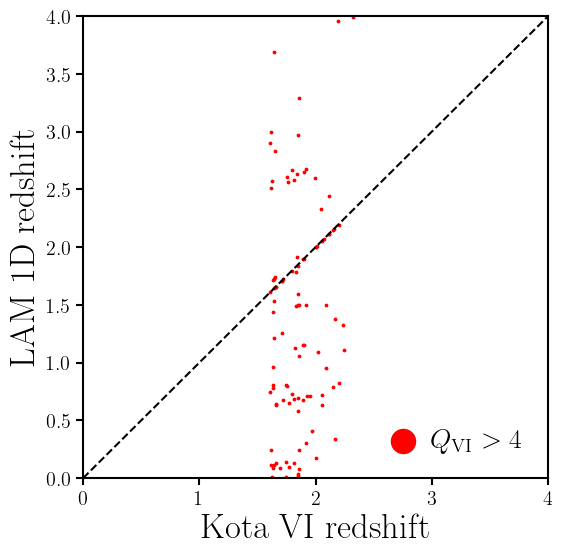

In [45]:
fig = plt.figure(figsize=(6,6))
sub = fig.add_subplot(111)
sub.plot([0., 4.], [0., 4.], c='k', ls='--')

vi_highz = (0.5*(kota['user1'] + kota['user2']) >= 4) & ((kota['z_measured'] > 1.6) & (kota['z_measured'] < 2.4))
sub.scatter(kota['z_measured'][vi_highz], lam1d_s25a['redshift'][i_match_kota][vi_highz], c='r', s=3, label=r'$Q_{\rm VI} > 4$')

print(np.mean(np.abs(kota['z_measured'][vi_highz] - lam1d_s25a['redshift'][i_match_kota][vi_highz]) < 0.01))


sub.legend(loc='lower right', fontsize=20, handletextpad=0, markerscale=10)
sub.set_xlabel(r'Kota VI redshift', fontsize=25)
sub.set_xlim(0., 4.)
sub.set_ylabel(r'LAM 1D redshift', fontsize=25)
sub.set_ylim(0., 4.)

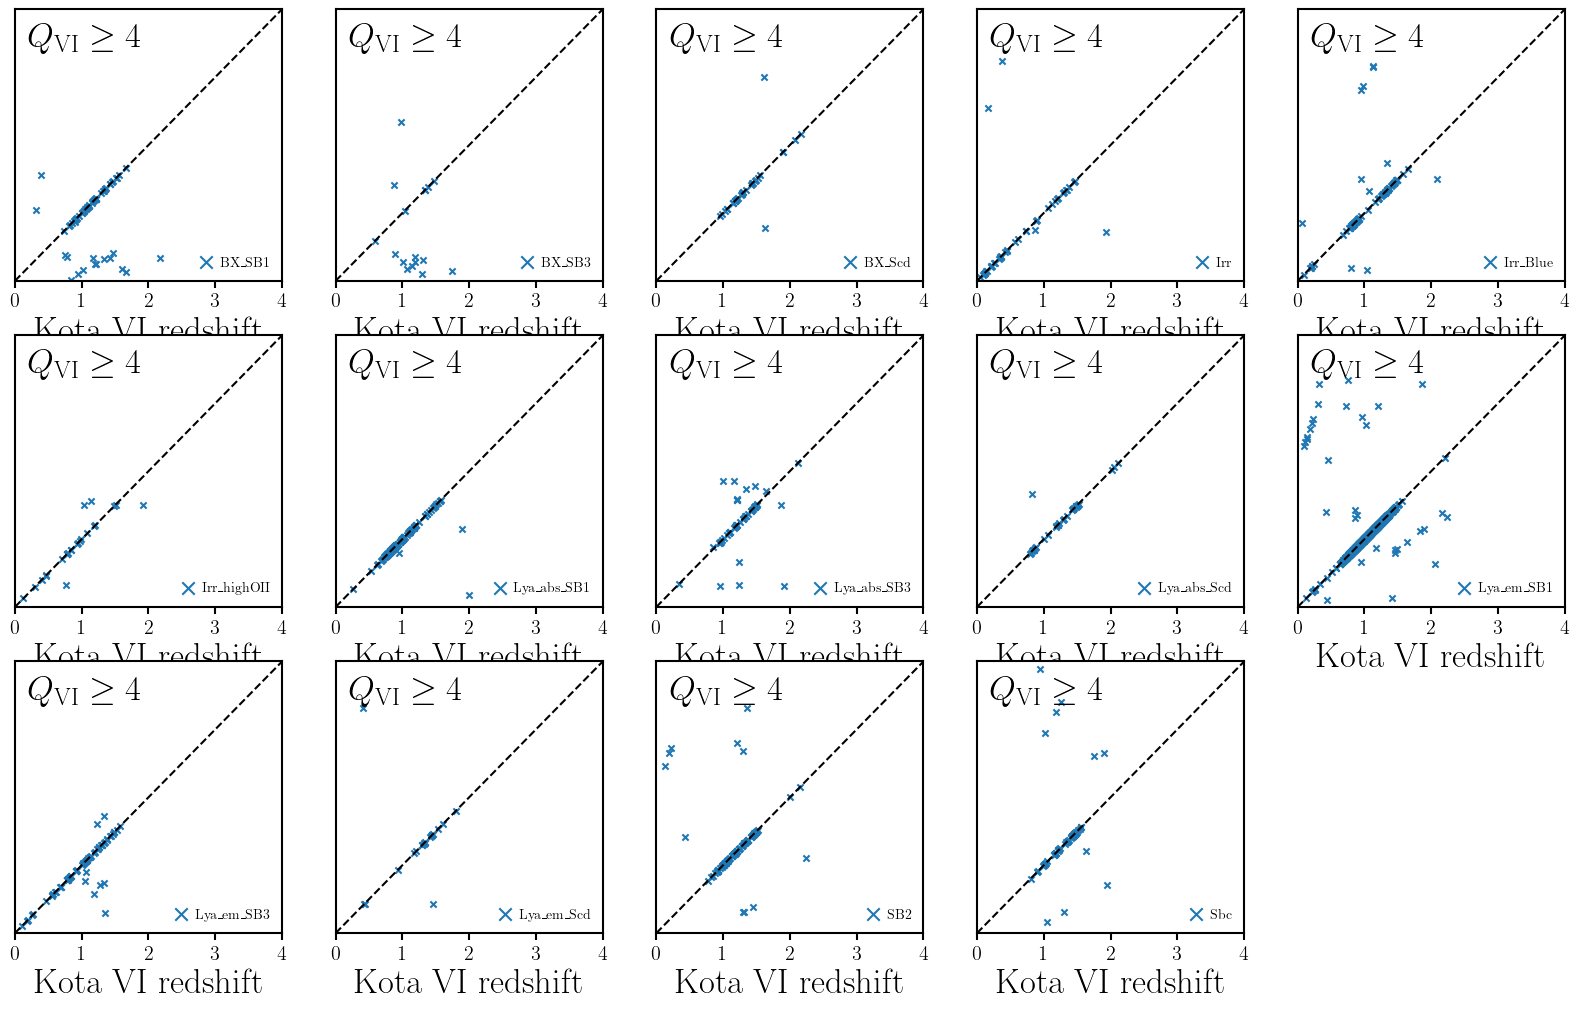

In [36]:
fig = plt.figure(figsize=(20, 12))
for i, subclass in enumerate(np.unique(lam1d_s25a['subClass'])): 
    sub = fig.add_subplot(3,5,i+1)
    sub.plot([0., 4.], [0., 4.], c='k', ls='--')
    
    q_thresh = 4.
    pass_vi = 0.5*(kota['user1'] + kota['user2']) >= q_thresh
    
    sub.text(0.05, 0.95, r'$Q_{\rm VI} \ge 4$', ha='left', va='top', transform=sub.transAxes, fontsize=25)
    is_sub = (lam1d_s25a['subClass'] == subclass)[i_match_kota]
    sub.scatter(kota['z_measured'][pass_vi & _best_z & is_sub], lam1d_s25a['redshift'][i_match_kota][pass_vi & _best_z & is_sub], 
                c='C0', marker='x', s=20, label=subclass)
    sub.legend(loc='lower right', fontsize=10, handletextpad=0, markerscale=2)
    sub.set_xlabel(r'Kota VI redshift', fontsize=25)
    sub.set_xlim(0., 4.)
    sub.set_ylim(0., 4.)
    sub.set_yticks([])

# color-cut 

In [46]:
# extinction corrected magnitudes 
g_mag = lam1d_s25a['g_cmodel_mag'] - lam1d_s25a['a_g']
r_mag = lam1d_s25a['r_cmodel_mag'] - lam1d_s25a['a_r']
i_mag = lam1d_s25a['i_cmodel_mag'] - lam1d_s25a['a_i']
z_mag = lam1d_s25a['z_cmodel_mag'] - lam1d_s25a['a_z']

In [47]:
# pass VI
pass_vi3 = 0.5*(kota['user1'] + kota['user2']) >= 3
pass_vi4 = 0.5*(kota['user1'] + kota['user2']) >= 4

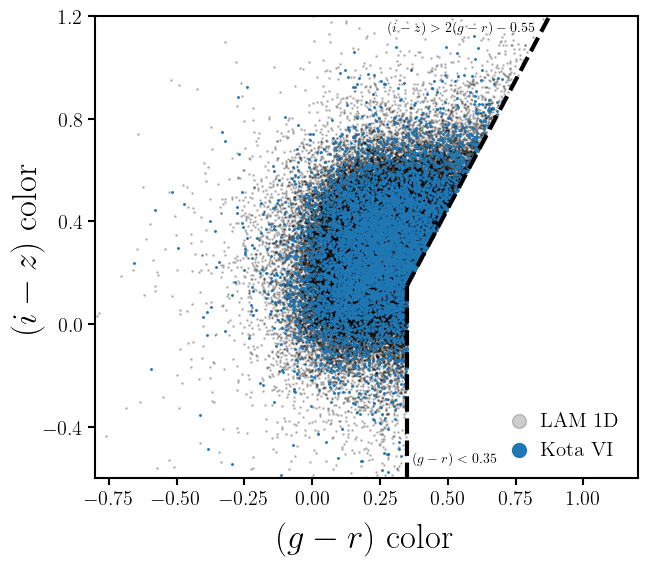

In [48]:
# (g-r) vs (i-z) figure
fig = plt.figure(figsize=(7,6))
sub = fig.add_subplot(111)

sub.scatter(
    (g_mag - r_mag), # (g-r)
    (i_mag - z_mag), # (i-z)
    c='k', s=1, alpha=0.2, label='LAM 1D')

sub.scatter(
    (g_mag - r_mag)[i_match_kota], # (g-r)
    (i_mag - z_mag)[i_match_kota], # (i-z)
    c='C0', s=1, label='Kota VI')
sub.legend(loc='lower right', fontsize=15, markerscale=10, handletextpad=0)

sub.plot([0.35, 0.35], [-0.6, 0.15], c='k', ls='--', lw=3)
sub.plot([0.35, 1.275], [0.15, 2], c='k', ls='--', lw=3)

sub.text(0.37, -0.5, '$(g-r) < 0.35$', ha='left', va='top', fontsize=10)
sub.text(0.825, 1.18, '$(i-z) > 2 (g-r) - 0.55$', ha='right', va='top', fontsize=10)
sub.set_xlim(-0.8, 1.2)
sub.set_ylim(-0.6, 1.2)
sub.set_yticks([-0.4, 0., 0.4, 0.8, 1.2])

bkgd = fig.add_subplot(111, frameon=False)
bkgd.set_xlabel(r'$(g - r)$ color', labelpad=10, fontsize=25) 
bkgd.set_ylabel(r'$(i - z)$ color', labelpad=10, fontsize=25) 
bkgd.tick_params(labelcolor='none', top=False, bottom=False, left=False, right=False)
# fig.subplots_adjust(wspace=0.1, right=0.8)

# cbar_ax = fig.add_axes([0.85, 0.15, 0.02, 0.7])
# cbar = fig.colorbar(hb, cax=cbar_ax)
# cbar.ax.set_ylabel(r'$N_{\rm gal}$', labelpad=25, fontsize=25, rotation=270)

In [49]:
# sample the colormaps that you want to use. Use 128 from each so we get 256
# colors in total
clrs1 = plt.cm.Blues(np.linspace(0.5, 1, 20))
clrs2 = plt.cm.Spectral_r(np.linspace(0.2, 1, 80))

# combine them and build a new colormap
colors = np.vstack((clrs2, clrs1))
mymap = mpl.colors.LinearSegmentedColormap.from_list('my_colormap', colors)

Text(0, 0.5, 'quality cut')

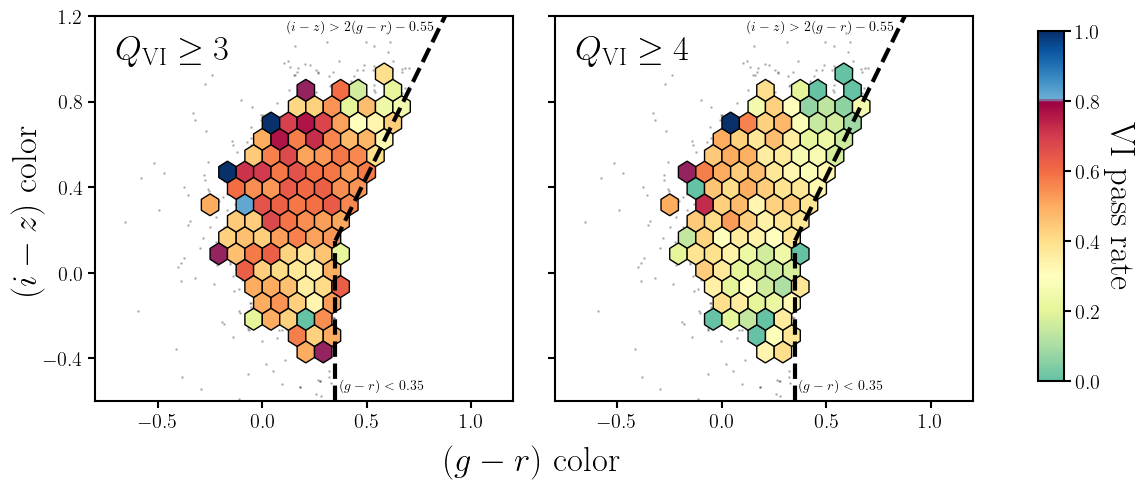

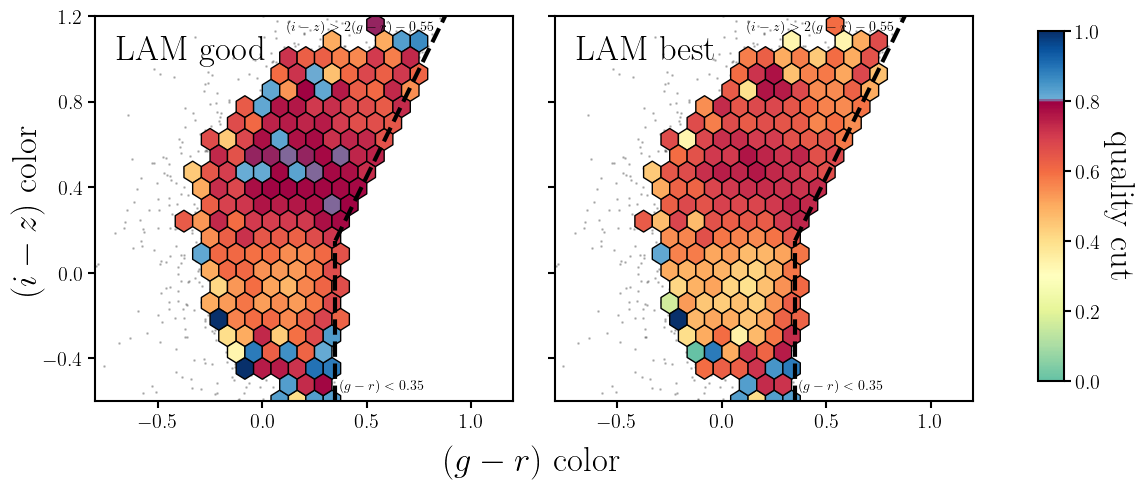

In [50]:
fig = plt.figure(figsize=(13,5))
sub = fig.add_subplot(121)

sub.scatter(
    (g_mag - r_mag)[i_match_kota], # (g-r)
    (i_mag - z_mag)[i_match_kota], # (i-z)
    c='k', s=1, alpha=0.2)
hb = sub.hexbin(
    (g_mag - r_mag)[i_match_kota], # (g-r)
    (i_mag - z_mag)[i_match_kota], # (i-z)
    C=pass_vi3.astype(float), 
    edgecolors='k', linewidth=1., reduce_C_function=np.mean, 
    extent=(-1, 1.5, -0.6, 2), gridsize=30, vmin=0., vmax=1., mincnt=5, cmap=mymap)#'Spectral_r')

sub.plot([0.35, 0.35], [-0.6, 0.15], c='k', ls='--', lw=3)
sub.plot([0.35, 1.275], [0.15, 2], c='k', ls='--', lw=3)

sub.text(0.05, 0.95, r'$Q_{\rm VI} \ge 3$', ha='left', va='top', transform=sub.transAxes, fontsize=25)

sub.text(0.37, -0.5, '$(g-r) < 0.35$', ha='left', va='top', fontsize=10)
sub.text(0.825, 1.18, '$(i-z) > 2 (g-r) - 0.55$', ha='right', va='top', fontsize=10)
sub.set_xlim(-0.8, 1.2)
sub.set_ylim(-0.6, 1.2)
sub.set_yticks([-0.4, 0., 0.4, 0.8, 1.2])

sub = fig.add_subplot(122)

sub.scatter(
    (g_mag - r_mag)[i_match_kota], # (g-r)
    (i_mag - z_mag)[i_match_kota], # (i-z)
    c='k', s=1, alpha=0.2)
hb = sub.hexbin(
    (g_mag - r_mag)[i_match_kota], # (g-r)
    (i_mag - z_mag)[i_match_kota], # (i-z)
    C=pass_vi4.astype(float), 
    edgecolors='k', linewidth=1., reduce_C_function=np.mean, 
    extent=(-1, 1.5, -0.6, 2), gridsize=30, vmin=0., vmax=1., mincnt=5, cmap=mymap)#'Spectral_r')

sub.plot([0.35, 0.35], [-0.6, 0.15], c='k', ls='--', lw=3)
sub.plot([0.35, 1.275], [0.15, 2], c='k', ls='--', lw=3)

sub.text(0.05, 0.95, r'$Q_{\rm VI} \ge 4$', ha='left', va='top', transform=sub.transAxes, fontsize=25)

sub.text(0.37, -0.5, '$(g-r) < 0.35$', ha='left', va='top', fontsize=10)
sub.text(0.825, 1.18, '$(i-z) > 2 (g-r) - 0.55$', ha='right', va='top', fontsize=10)
sub.set_xlim(-0.8, 1.2)
sub.set_ylim(-0.6, 1.2)
sub.set_yticks([-0.4, 0., 0.4, 0.8, 1.2])
sub.set_yticklabels([])

bkgd = fig.add_subplot(111, frameon=False)
bkgd.set_xlabel(r'$(g - r)$ color', labelpad=10, fontsize=25) 
bkgd.set_ylabel(r'$(i - z)$ color', labelpad=10, fontsize=25) 
bkgd.tick_params(labelcolor='none', top=False, bottom=False, left=False, right=False)
fig.subplots_adjust(wspace=0.1, right=0.8)

cbar_ax = fig.add_axes([0.85, 0.15, 0.02, 0.7])
cbar = fig.colorbar(hb, cax=cbar_ax)
cbar.ax.set_ylabel(r'VI pass rate', labelpad=25, fontsize=25, rotation=270)


fig = plt.figure(figsize=(13,5))
sub = fig.add_subplot(121)

sub.scatter(
    (g_mag - r_mag), # (g-r)
    (i_mag - z_mag), # (i-z)
    c='k', s=1, alpha=0.2)
hb = sub.hexbin(
    (g_mag - r_mag), # (g-r)
    (i_mag - z_mag), # (i-z)
    C=good_lam.astype(float), 
    edgecolors='k', linewidth=1., reduce_C_function=np.mean, 
    extent=(-1, 1.5, -0.6, 2), gridsize=30, vmin=0., vmax=1., mincnt=5, cmap=mymap)#'Spectral_r')

sub.plot([0.35, 0.35], [-0.6, 0.15], c='k', ls='--', lw=3)
sub.plot([0.35, 1.275], [0.15, 2], c='k', ls='--', lw=3)

sub.text(0.05, 0.95, r'LAM good', ha='left', va='top', transform=sub.transAxes, fontsize=25)

sub.text(0.37, -0.5, '$(g-r) < 0.35$', ha='left', va='top', fontsize=10)
sub.text(0.825, 1.18, '$(i-z) > 2 (g-r) - 0.55$', ha='right', va='top', fontsize=10)
sub.set_xlim(-0.8, 1.2)
sub.set_ylim(-0.6, 1.2)
sub.set_yticks([-0.4, 0., 0.4, 0.8, 1.2])

sub = fig.add_subplot(122)

sub.scatter(
    (g_mag - r_mag), # (g-r)
    (i_mag - z_mag), # (i-z)
    c='k', s=1, alpha=0.2)
hb = sub.hexbin(
    (g_mag - r_mag), # (g-r)
    (i_mag - z_mag), # (i-z)
    C=best_lam.astype(float), 
    edgecolors='k', linewidth=1., reduce_C_function=np.mean, 
    extent=(-1, 1.5, -0.6, 2), gridsize=30, vmin=0., vmax=1., mincnt=5, cmap=mymap)#'Spectral_r')

sub.plot([0.35, 0.35], [-0.6, 0.15], c='k', ls='--', lw=3)
sub.plot([0.35, 1.275], [0.15, 2], c='k', ls='--', lw=3)

sub.text(0.05, 0.95, r'LAM best', ha='left', va='top', transform=sub.transAxes, fontsize=25)

sub.text(0.37, -0.5, '$(g-r) < 0.35$', ha='left', va='top', fontsize=10)
sub.text(0.825, 1.18, '$(i-z) > 2 (g-r) - 0.55$', ha='right', va='top', fontsize=10)
sub.set_xlim(-0.8, 1.2)
sub.set_ylim(-0.6, 1.2)
sub.set_yticks([-0.4, 0., 0.4, 0.8, 1.2])
sub.set_yticklabels([])

bkgd = fig.add_subplot(111, frameon=False)
bkgd.set_xlabel(r'$(g - r)$ color', labelpad=10, fontsize=25) 
bkgd.set_ylabel(r'$(i - z)$ color', labelpad=10, fontsize=25) 
bkgd.tick_params(labelcolor='none', top=False, bottom=False, left=False, right=False)
fig.subplots_adjust(wspace=0.1, right=0.8)

cbar_ax = fig.add_axes([0.85, 0.15, 0.02, 0.7])
cbar = fig.colorbar(hb, cax=cbar_ax)
cbar.ax.set_ylabel(r'quality cut', labelpad=25, fontsize=25, rotation=270)

Text(0, 0.5, 'LAM 1D $z$')

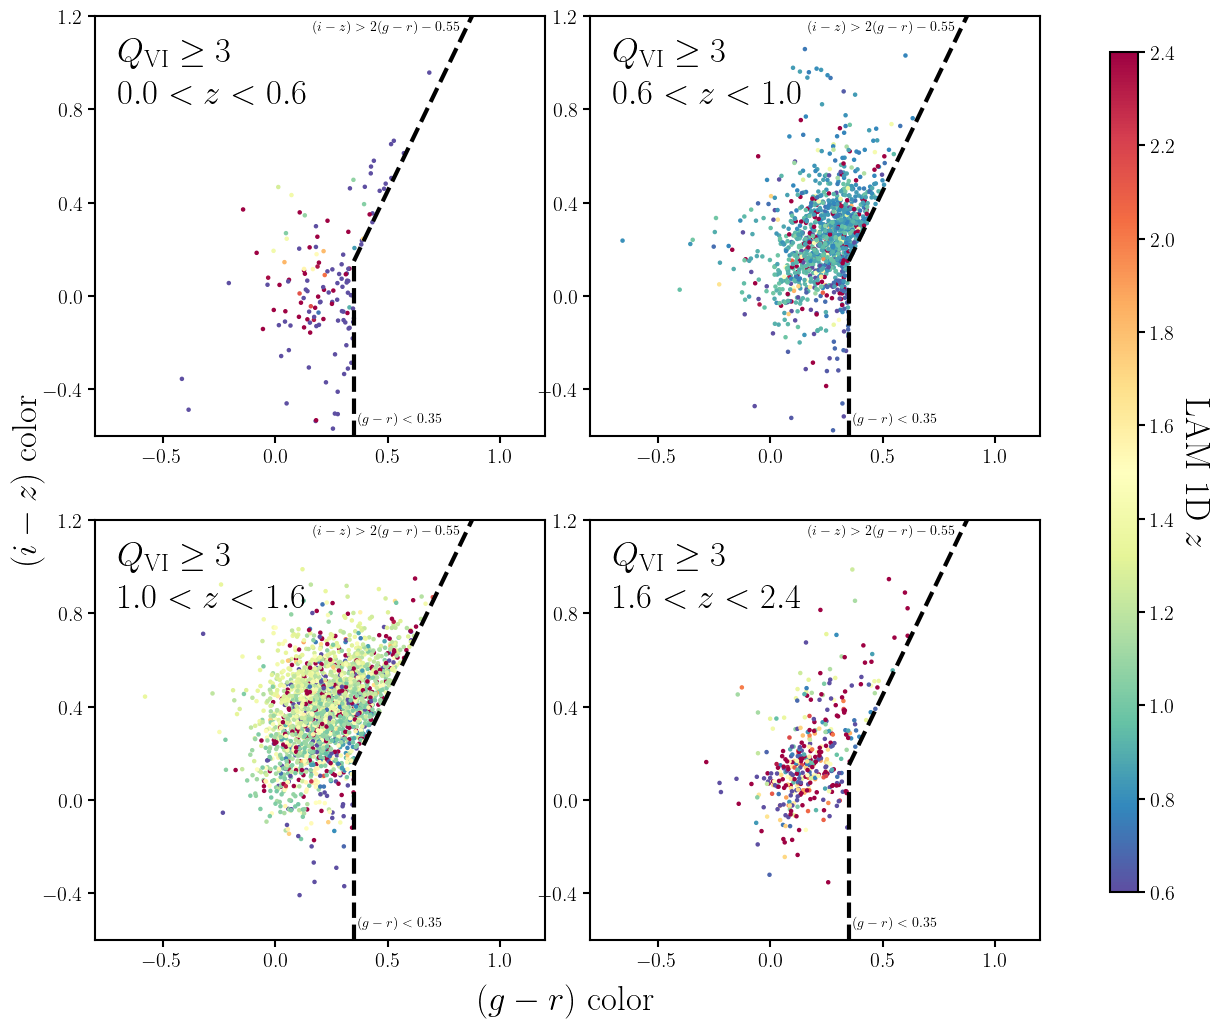

In [52]:
fig = plt.figure(figsize=(14, 12))
for i in range(4): 
    sub = fig.add_subplot(2,2,i+1)

    zlim = ((kota['z_measured'] > [0, 0.6, 1., 1.6][i]) & (kota['z_measured'] < [0.6, 1., 1.6, 2.4][i]) &
            (0.5*(kota['user1'] + kota['user2']) >= 3))
    hb = sub.scatter(
        (g_mag - r_mag)[i_match_kota][zlim], # (g-r)
        (i_mag - z_mag)[i_match_kota][zlim], # (i-z)
        c=lam1d_s25a[i_match_kota]['redshift'][zlim], s=5, vmin=0.6, vmax=2.4, cmap='Spectral_r')

    sub.text(0.05, 0.95, r'$Q_{\rm VI} \ge 3$', ha='left', va='top', transform=sub.transAxes, fontsize=25)
    sub.text(0.05, 0.85, r'$%.1f < z < %.1f$' % ([0, 0.6, 1., 1.6][i], [0.6, 1., 1.6, 2.4][i]), ha='left', va='top', transform=sub.transAxes, fontsize=25)
    
    sub.plot([0.35, 0.35], [-0.6, 0.15], c='k', ls='--', lw=3)
    sub.plot([0.35, 1.275], [0.15, 2], c='k', ls='--', lw=3)
    
    sub.text(0.37, -0.5, '$(g-r) < 0.35$', ha='left', va='top', fontsize=10)
    sub.text(0.825, 1.18, '$(i-z) > 2 (g-r) - 0.55$', ha='right', va='top', fontsize=10)
    sub.set_xlim(-0.8, 1.2)
    sub.set_ylim(-0.6, 1.2)
    sub.set_yticks([-0.4, 0., 0.4, 0.8, 1.2])

bkgd = fig.add_subplot(111, frameon=False)
bkgd.set_xlabel(r'$(g - r)$ color', labelpad=10, fontsize=25) 
bkgd.set_ylabel(r'$(i - z)$ color', labelpad=10, fontsize=25) 
bkgd.tick_params(labelcolor='none', top=False, bottom=False, left=False, right=False)
fig.subplots_adjust(wspace=0.1, right=0.8)

cbar_ax = fig.add_axes([0.85, 0.15, 0.02, 0.7])
cbar = fig.colorbar(hb, cax=cbar_ax)
cbar.ax.set_ylabel(r'LAM 1D $z$', labelpad=25, fontsize=25, rotation=270)

Text(0, 0.5, 'LAM 1D $z$')

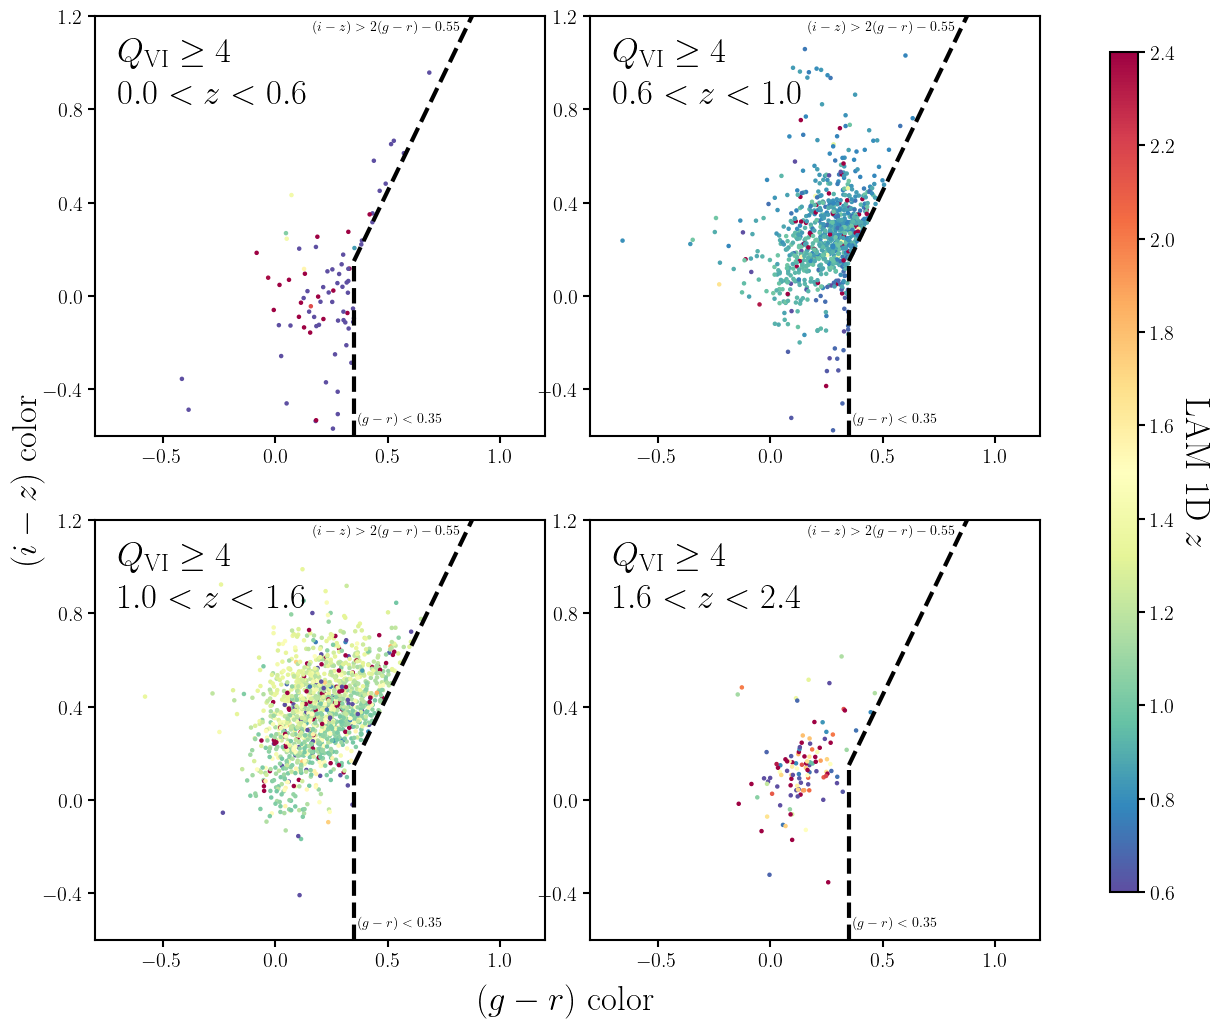

In [53]:
fig = plt.figure(figsize=(14, 12))
for i in range(4): 
    sub = fig.add_subplot(2,2,i+1)

    zlim = ((kota['z_measured'] > [0, 0.6, 1., 1.6][i]) & (kota['z_measured'] < [0.6, 1., 1.6, 2.4][i]) &
            (0.5*(kota['user1'] + kota['user2']) >= 4))
    hb = sub.scatter(
        (g_mag - r_mag)[i_match_kota][zlim], # (g-r)
        (i_mag - z_mag)[i_match_kota][zlim], # (i-z)
        c=lam1d_s25a[i_match_kota]['redshift'][zlim], s=5, vmin=0.6, vmax=2.4, cmap='Spectral_r')

    sub.text(0.05, 0.95, r'$Q_{\rm VI} \ge 4$', ha='left', va='top', transform=sub.transAxes, fontsize=25)
    sub.text(0.05, 0.85, r'$%.1f < z < %.1f$' % ([0, 0.6, 1., 1.6][i], [0.6, 1., 1.6, 2.4][i]), ha='left', va='top', transform=sub.transAxes, fontsize=25)
    
    sub.plot([0.35, 0.35], [-0.6, 0.15], c='k', ls='--', lw=3)
    sub.plot([0.35, 1.275], [0.15, 2], c='k', ls='--', lw=3)
    
    sub.text(0.37, -0.5, '$(g-r) < 0.35$', ha='left', va='top', fontsize=10)
    sub.text(0.825, 1.18, '$(i-z) > 2 (g-r) - 0.55$', ha='right', va='top', fontsize=10)
    sub.set_xlim(-0.8, 1.2)
    sub.set_ylim(-0.6, 1.2)
    sub.set_yticks([-0.4, 0., 0.4, 0.8, 1.2])

bkgd = fig.add_subplot(111, frameon=False)
bkgd.set_xlabel(r'$(g - r)$ color', labelpad=10, fontsize=25) 
bkgd.set_ylabel(r'$(i - z)$ color', labelpad=10, fontsize=25) 
bkgd.tick_params(labelcolor='none', top=False, bottom=False, left=False, right=False)
fig.subplots_adjust(wspace=0.1, right=0.8)

cbar_ax = fig.add_axes([0.85, 0.15, 0.02, 0.7])
cbar = fig.colorbar(hb, cax=cbar_ax)
cbar.ax.set_ylabel(r'LAM 1D $z$', labelpad=25, fontsize=25, rotation=270)

Text(0, 0.5, '$z$')

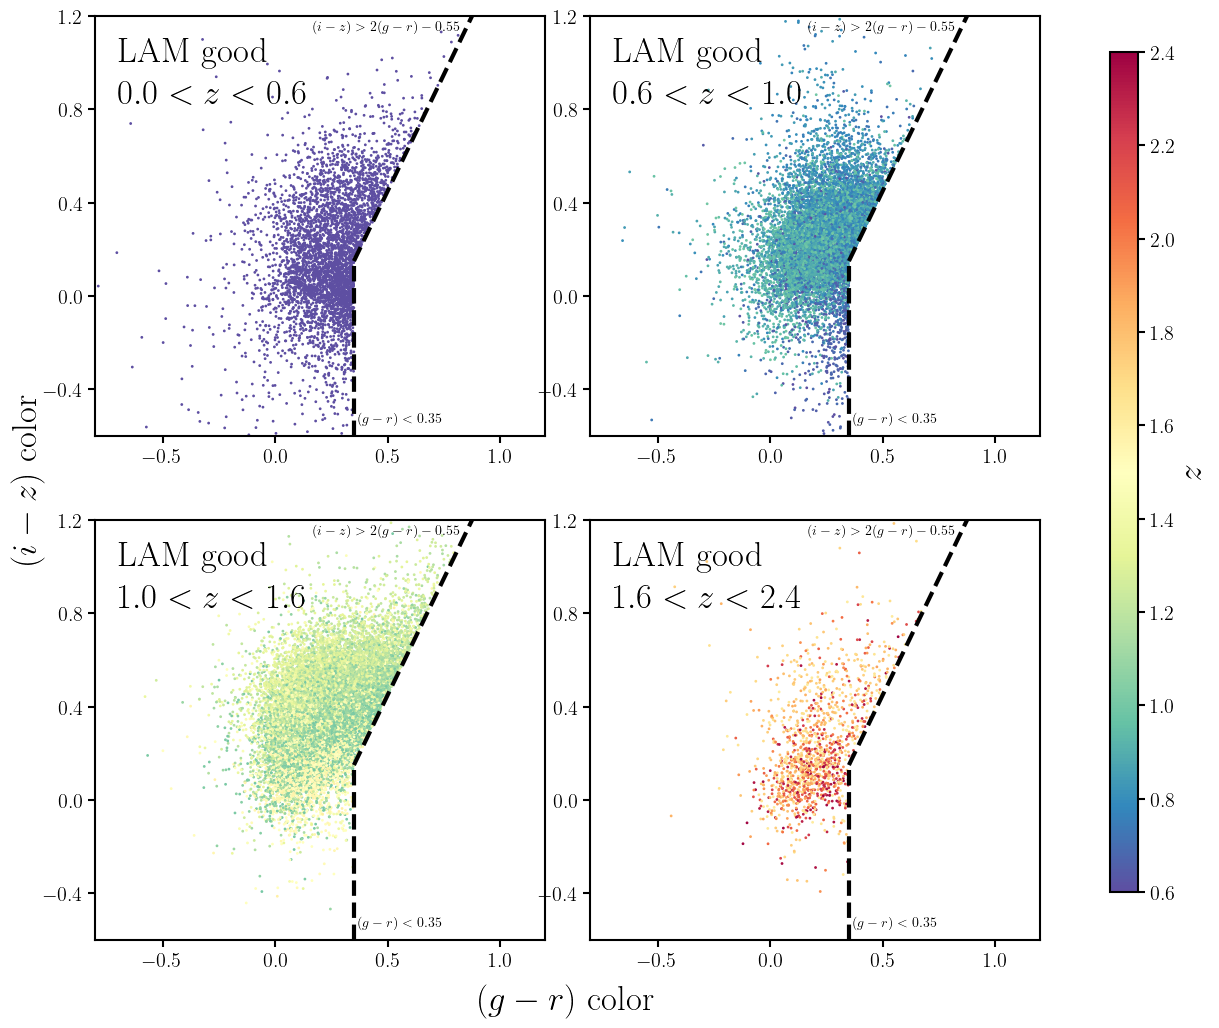

In [55]:
fig = plt.figure(figsize=(14, 12))
for i in range(4): 
    sub = fig.add_subplot(2,2,i+1)

    zlim = ((lam1d_s25a['redshift'] > [0, 0.6, 1., 1.6][i]) & (lam1d_s25a['redshift'] < [0.6, 1., 1.6, 2.4][i]) &
            good_lam)
    hb = sub.scatter(
        (g_mag - r_mag)[zlim], # (g-r)
        (i_mag - z_mag)[zlim], # (i-z)
        c=lam1d_s25a['redshift'][zlim], s=1, vmin=0.6, vmax=2.4, cmap='Spectral_r')

    sub.text(0.05, 0.95, r'LAM good', ha='left', va='top', transform=sub.transAxes, fontsize=25)
    sub.text(0.05, 0.85, r'$%.1f < z < %.1f$' % ([0, 0.6, 1., 1.6][i], [0.6, 1., 1.6, 2.4][i]), ha='left', va='top', transform=sub.transAxes, fontsize=25)
    
    sub.plot([0.35, 0.35], [-0.6, 0.15], c='k', ls='--', lw=3)
    sub.plot([0.35, 1.275], [0.15, 2], c='k', ls='--', lw=3)
    
    sub.text(0.37, -0.5, '$(g-r) < 0.35$', ha='left', va='top', fontsize=10)
    sub.text(0.825, 1.18, '$(i-z) > 2 (g-r) - 0.55$', ha='right', va='top', fontsize=10)
    sub.set_xlim(-0.8, 1.2)
    sub.set_ylim(-0.6, 1.2)
    sub.set_yticks([-0.4, 0., 0.4, 0.8, 1.2])

bkgd = fig.add_subplot(111, frameon=False)
bkgd.set_xlabel(r'$(g - r)$ color', labelpad=10, fontsize=25) 
bkgd.set_ylabel(r'$(i - z)$ color', labelpad=10, fontsize=25) 
bkgd.tick_params(labelcolor='none', top=False, bottom=False, left=False, right=False)
fig.subplots_adjust(wspace=0.1, right=0.8)

cbar_ax = fig.add_axes([0.85, 0.15, 0.02, 0.7])
cbar = fig.colorbar(hb, cax=cbar_ax)
cbar.ax.set_ylabel(r'$z$', labelpad=25, fontsize=25, rotation=270)

Text(0, 0.5, '$z$')

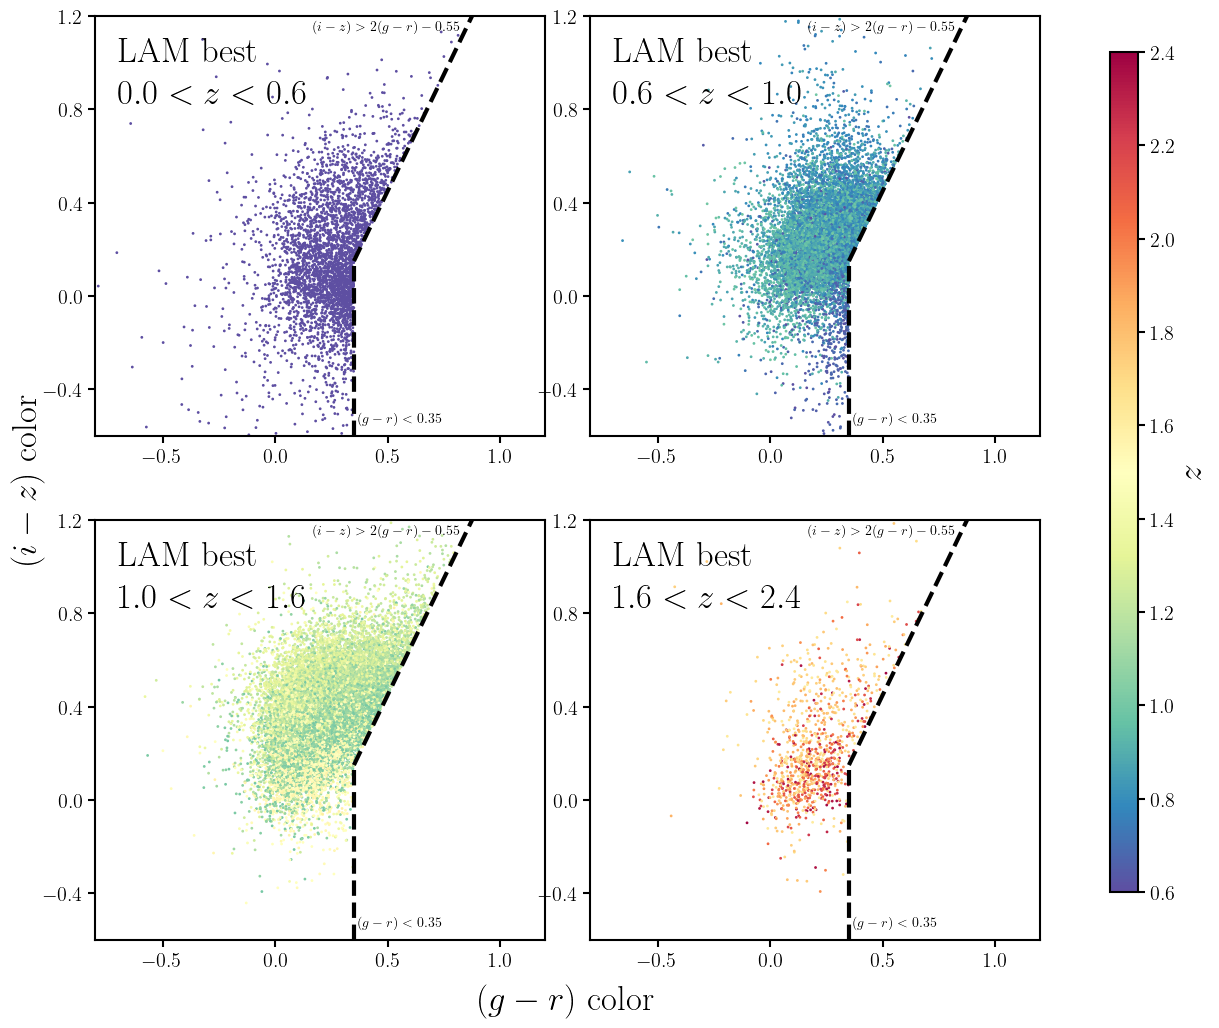

In [56]:
fig = plt.figure(figsize=(14, 12))
for i in range(4): 
    sub = fig.add_subplot(2,2,i+1)

    zlim = ((lam1d_s25a['redshift'] > [0, 0.6, 1., 1.6][i]) & (lam1d_s25a['redshift'] < [0.6, 1., 1.6, 2.4][i]) &
            best_lam)
    hb = sub.scatter(
        (g_mag - r_mag)[zlim], # (g-r)
        (i_mag - z_mag)[zlim], # (i-z)
        c=lam1d_s25a['redshift'][zlim], s=1, vmin=0.6, vmax=2.4, cmap='Spectral_r')

    sub.text(0.05, 0.95, r'LAM best', ha='left', va='top', transform=sub.transAxes, fontsize=25)
    sub.text(0.05, 0.85, r'$%.1f < z < %.1f$' % ([0, 0.6, 1., 1.6][i], [0.6, 1., 1.6, 2.4][i]), ha='left', va='top', transform=sub.transAxes, fontsize=25)
    
    sub.plot([0.35, 0.35], [-0.6, 0.15], c='k', ls='--', lw=3)
    sub.plot([0.35, 1.275], [0.15, 2], c='k', ls='--', lw=3)
    
    sub.text(0.37, -0.5, '$(g-r) < 0.35$', ha='left', va='top', fontsize=10)
    sub.text(0.825, 1.18, '$(i-z) > 2 (g-r) - 0.55$', ha='right', va='top', fontsize=10)
    sub.set_xlim(-0.8, 1.2)
    sub.set_ylim(-0.6, 1.2)
    sub.set_yticks([-0.4, 0., 0.4, 0.8, 1.2])

bkgd = fig.add_subplot(111, frameon=False)
bkgd.set_xlabel(r'$(g - r)$ color', labelpad=10, fontsize=25) 
bkgd.set_ylabel(r'$(i - z)$ color', labelpad=10, fontsize=25) 
bkgd.tick_params(labelcolor='none', top=False, bottom=False, left=False, right=False)
fig.subplots_adjust(wspace=0.1, right=0.8)

cbar_ax = fig.add_axes([0.85, 0.15, 0.02, 0.7])
cbar = fig.colorbar(hb, cax=cbar_ax)
cbar.ax.set_ylabel(r'$z$', labelpad=25, fontsize=25, rotation=270)

3715
12933
17958
1012


Text(0, 0.5, '$z$')

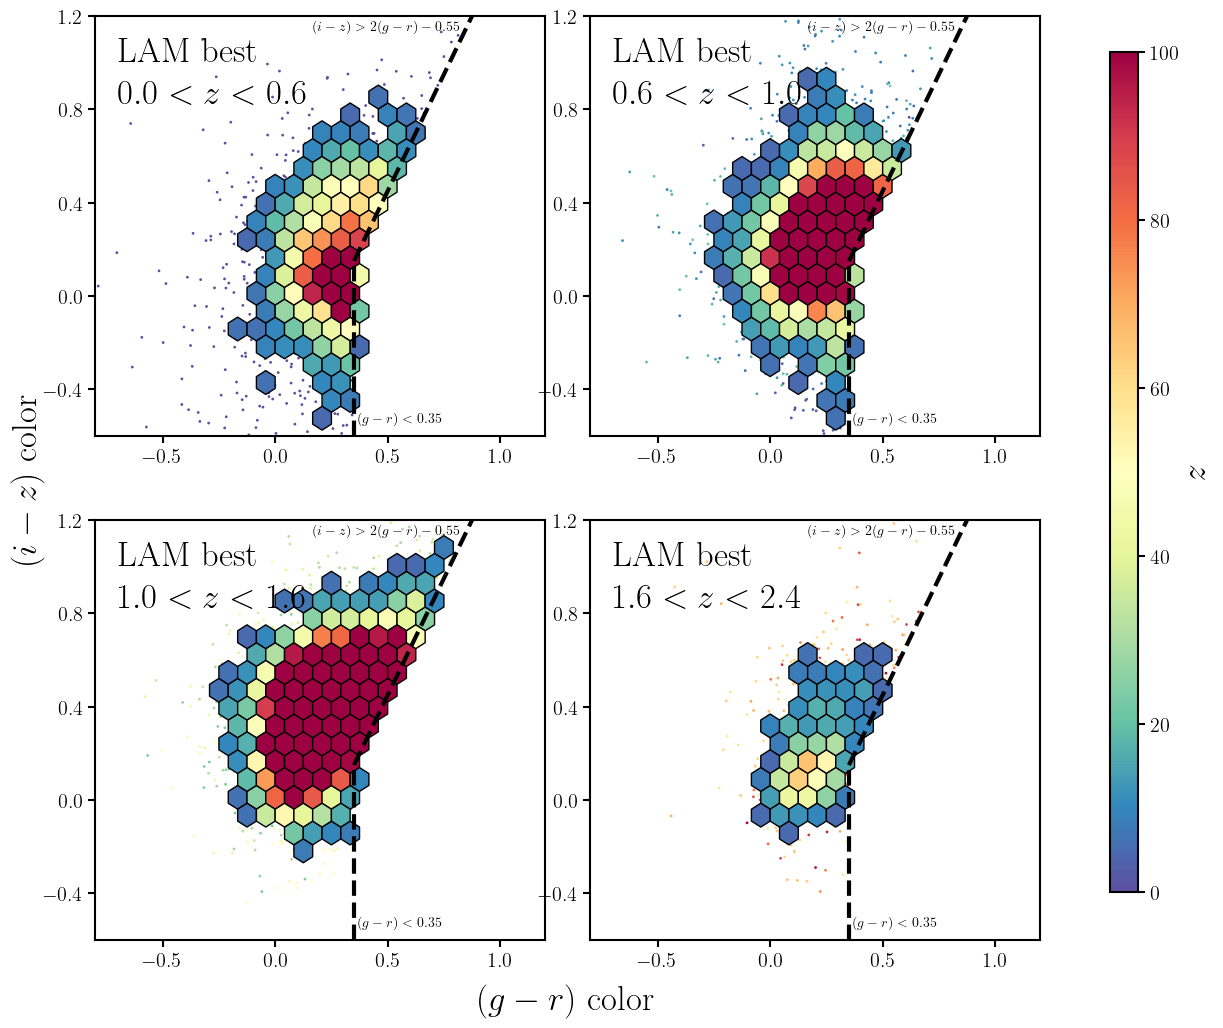

In [64]:
fig = plt.figure(figsize=(14, 12))
for i in range(4): 
    sub = fig.add_subplot(2,2,i+1)

    zlim = ((lam1d_s25a['redshift'] > [0, 0.6, 1., 1.6][i]) & (lam1d_s25a['redshift'] < [0.6, 1., 1.6, 2.4][i]) &
            best_lam)
    print(np.sum(zlim))
    hb = sub.scatter(
        (g_mag - r_mag)[zlim], # (g-r)
        (i_mag - z_mag)[zlim], # (i-z)
        c=lam1d_s25a['redshift'][zlim], s=1, vmin=0.6, vmax=2.4, cmap='Spectral_r')
    hb = sub.hexbin(
        (g_mag - r_mag)[zlim], # (g-r)
        (i_mag - z_mag)[zlim], # (i-z)
        C=np.ones(len(zlim))[zlim],
        edgecolors='k', linewidth=1., reduce_C_function=np.sum, 
        extent=(-1, 1.5, -0.6, 2), gridsize=30, vmin=0., vmax=100., mincnt=5, cmap='Spectral_r')

    sub.text(0.05, 0.95, r'LAM best', ha='left', va='top', transform=sub.transAxes, fontsize=25)
    sub.text(0.05, 0.85, r'$%.1f < z < %.1f$' % ([0, 0.6, 1., 1.6][i], [0.6, 1., 1.6, 2.4][i]), ha='left', va='top', transform=sub.transAxes, fontsize=25)
    
    sub.plot([0.35, 0.35], [-0.6, 0.15], c='k', ls='--', lw=3)
    sub.plot([0.35, 1.275], [0.15, 2], c='k', ls='--', lw=3)
    
    sub.text(0.37, -0.5, '$(g-r) < 0.35$', ha='left', va='top', fontsize=10)
    sub.text(0.825, 1.18, '$(i-z) > 2 (g-r) - 0.55$', ha='right', va='top', fontsize=10)
    sub.set_xlim(-0.8, 1.2)
    sub.set_ylim(-0.6, 1.2)
    sub.set_yticks([-0.4, 0., 0.4, 0.8, 1.2])

bkgd = fig.add_subplot(111, frameon=False)
bkgd.set_xlabel(r'$(g - r)$ color', labelpad=10, fontsize=25) 
bkgd.set_ylabel(r'$(i - z)$ color', labelpad=10, fontsize=25) 
bkgd.tick_params(labelcolor='none', top=False, bottom=False, left=False, right=False)
fig.subplots_adjust(wspace=0.1, right=0.8)

cbar_ax = fig.add_axes([0.85, 0.15, 0.02, 0.7])
cbar = fig.colorbar(hb, cax=cbar_ax)
cbar.ax.set_ylabel(r'$z$', labelpad=25, fontsize=25, rotation=270)